In [1]:
# Transformers example -> Reverseing sequence of numbers
print("Hey")

Hey


In [2]:
import haiku as hk
import jax
import jax.numpy as jnp
import jax.random as jrandom
import matplotlib.pyplot as plt
import optax

from probjax.nn.transformers import Transformer
from probjax.utils.odeint import _odeint

jax.devices()

I0000 00:00:1699903761.983184   61522 tfrt_cpu_pjrt_client.cc:349] TfrtCpuClient created.
2023-11-13 20:29:24.578612: W external/xla/xla/service/gpu/nvptx_compiler.cc:708] The NVIDIA driver's CUDA version is 11.7 which is older than the ptxas CUDA version (11.8.89). Because the driver is older than the ptxas version, XLA is disabling parallel compilation, which may slow down compilation. You should update your NVIDIA driver or use the NVIDIA-provided CUDA forward compatibility packages.


[gpu(id=0),
 gpu(id=1),
 gpu(id=2),
 gpu(id=3),
 gpu(id=4),
 gpu(id=5),
 gpu(id=6),
 gpu(id=7)]

In [3]:
jax.devices("cpu")

[CpuDevice(id=0)]

In [4]:
jax.devices("gpu")

[gpu(id=0),
 gpu(id=1),
 gpu(id=2),
 gpu(id=3),
 gpu(id=4),
 gpu(id=5),
 gpu(id=6),
 gpu(id=7)]

In [5]:
ts = jnp.linspace(0, 50, 500)

def beta_fn(t, betas):
    y = jnp.interp(t, ts, betas)
    return y


dW = jrandom.normal(jrandom.PRNGKey(2), (499, )) * jnp.sqrt(0.01)
Wt = jnp.cumsum(dW, axis=0)
Wt = jnp.concatenate([jnp.zeros((1,)), Wt], axis=0)
Wt = jnp.cumsum(Wt, axis=0)
betas = jax.nn.sigmoid(Wt*0.1)

def sir_model(t, y, gamma, delta, betas):
    S, I, R,D = y
    dSdt = -beta_fn(t, betas) * S * I
    dIdt = beta_fn(t, betas) * S * I - (gamma + delta) * I
    dRdt = gamma * I
    dDdt = delta * I
    return dSdt, dIdt, dRdt,dDdt

S0 = 1.
I0 = 0.1
R0 = 0.0
D0 = 0.0

gamma = 0.2
delta = 0.01

ys = _odeint(sir_model, (S0, I0, R0,D0), ts, gamma, delta, betas)

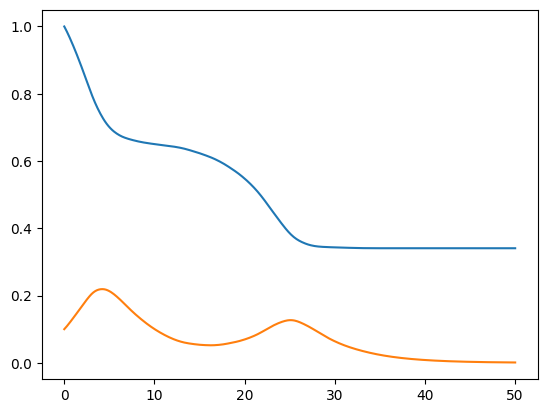

In [6]:
_ = plt.plot(ts,ys[0])
_ = plt.plot(ts,ys[1])

In [7]:
num_timeponts = 50
time_start = 0
time_end = 20
ts_dense = jnp.linspace(time_start, time_end, 100)

def beta_fn(t, betas):
    y = jnp.interp(t, ts_dense, betas)
    return y


def generate_data(key, n):

    key1, key2, key3, key4, key5, key6, key7, key_t = jrandom.split(key, 8)

    gamma = jrandom.uniform(key1, (n,1), minval=0., maxval=1.)
    delta = jrandom.uniform(key2, (n,1), minval=0., maxval=1.)

    dW = jrandom.normal(key3, (n,len(ts_dense)-1,)) * jnp.sqrt(0.01)
    Wt = jnp.cumsum(dW, axis=1)  / ts_dense[None, 1:]
    Wt = jnp.concatenate([jnp.zeros((n,1)), Wt], axis=1)
    Wt = jnp.cumsum(Wt, axis=1) #+ jnp.sin(ts_dense[None, :])*0.1
    betas = jax.nn.sigmoid(Wt)*4

    # Random time points
    key_t1, key_t2, key_t3, key_t4 = jrandom.split(key_t, 4)
    ts1 = jrandom.uniform(key_t1, (n , num_timeponts), minval=time_start, maxval=time_end)
    ts2 = jrandom.uniform(key_t2, (n , num_timeponts), minval=time_start, maxval=time_end)
    ts3 = jrandom.uniform(key_t3, (n , num_timeponts), minval=time_start, maxval=time_end)
    ts4 = jrandom.uniform(key_t4, (n , num_timeponts), minval=time_start, maxval=time_end)
    I0 = jrandom.uniform(key4, (), minval=0., maxval=0.2)
    S, I, R, D = jax.vmap(lambda *args: _odeint(*args), in_axes=(None, None, None, 0,0,0))(sir_model, (S0, I0, R0, D0), ts_dense, gamma, delta, betas)
    betas = jax.vmap(lambda *args: jnp.interp(*args), in_axes=(0, None, 0))(ts1, ts_dense, betas)
    I = jax.vmap(lambda *args: jnp.interp(*args), in_axes=(0, None, 0))(ts2, ts_dense, I)
    D = jax.vmap(lambda *args: jnp.interp(*args), in_axes=(0, None, 0))(ts3, ts_dense, D)
    R = jax.vmap(lambda *args: jnp.interp(*args), in_axes=(0, None, 0))(ts4, ts_dense, R)

    I = I + jrandom.normal(key5, I.shape) * 0.001
    D = D + jrandom.normal(key6, D.shape) * 0.001
    R = R + jrandom.normal(key6, R.shape) * 0.001

    node_ids = jnp.array([0, 1,] + [4] * num_timeponts + [5] * num_timeponts + [6] * num_timeponts + [7] * num_timeponts)
    node_metadata = jnp.concatenate([jnp.full((n, 1), jnp.nan), jnp.full((n, 1), jnp.nan),ts1,ts2,ts3, ts4], axis=1).reshape((n, -1, 1))
    full_data = jnp.concatenate([gamma, delta, betas, I,D,R], axis=1).reshape((n, -1, 1))
    return full_data, node_ids, node_metadata


data, node_ids, node_metadata = generate_data(jrandom.PRNGKey(1
                                                              ), 200)
mean = data.mean(axis=0)
std = data.std(axis=0)
T_max = data.shape[1]

print(T_max)

202


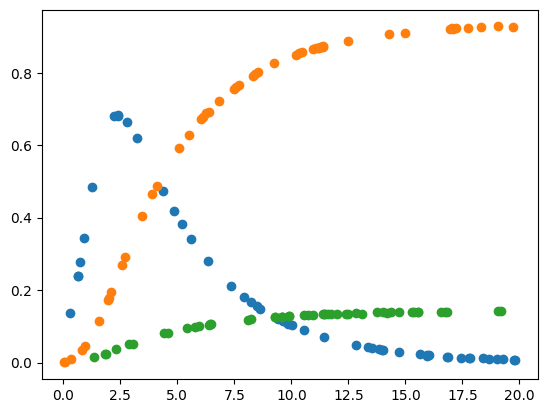

In [8]:
time_evals1 = node_metadata[:, 2+num_timeponts : 2 + num_timeponts*2]
time_evals2 = node_metadata[:, 2+num_timeponts*2 : 2 + num_timeponts*3]
time_evals3 = node_metadata[:, 2+num_timeponts*3 : 2 + num_timeponts*4]
betas = data[:, 2:2+num_timeponts]
I = data[:, 2+num_timeponts:2 + num_timeponts*2]
D = data[:, 2+num_timeponts*2:2 + num_timeponts*3]
R = data[:, 2+num_timeponts*3:2 + num_timeponts*4]

for i in range(1):
    plt.scatter(time_evals1[i], I[i], c='C0')
    plt.scatter(time_evals2[i], D[i], c='C1')
    plt.scatter(time_evals3[i], R[i], c='C2')


In [9]:
key = jrandom.PRNGKey(0)

In [10]:
from probjax.nn.helpers import SinusoidalEmbedding

In [21]:

def model(t, x, node_ids, node_metadata, condition_mask):
    condition_mask = condition_mask.astype(int)
    # Embed values and conditions

    dim = 210
    _dim = dim // 3
    embedding_net = hk.nets.MLP([dim, _dim])
    embedding_id_nets = hk.Embed(T_max, _dim, w_init=hk.initializers.RandomNormal(stddev=2.))
    embedding_metadata = SinusoidalEmbedding(_dim)
    embedding_time = SinusoidalEmbedding(_dim)


    # Positional embedding

    model = Transformer(num_heads=4, num_layers=4, attn_size=50, dropout_rate=0.0, widening_factor=4)

    # Embed values adn time
    value_embeddings = embedding_net(x)
    time_embeddings = embedding_time(t.reshape(-1,1,1))
    time_embeddings = jnp.broadcast_to(time_embeddings, value_embeddings.shape[:-1] + (_dim,))

    # Embed node ids and metadata
    id_embeddings = embedding_id_nets(node_ids.reshape(-1,x.shape[1]))
    metadata_embeddings = embedding_metadata(node_metadata.reshape(-1,x.shape[1],1))
    metadata_embeddings = metadata_embeddings * ~jnp.isnan(metadata_embeddings)
    metadata_embeddings = jnp.broadcast_to(metadata_embeddings, value_embeddings.shape)
    id_embeddings = jnp.broadcast_to(id_embeddings, value_embeddings.shape)
    node_emebding = id_embeddings

    # Condition embedding
    condition_embedding = hk.get_parameter("condition_embedding", shape=(dim,), init=hk.initializers.RandomNormal())
    condition_embedding = condition_embedding.reshape(1,1, -1) * condition_mask.reshape(-1, x.shape[1],1)



    x_encoded = jnp.concatenate([value_embeddings, node_emebding, metadata_embeddings], axis=-1)
    x_encoded = x_encoded + condition_embedding

    # Encode
    h = model(x_encoded, context=time_embeddings)

    # Decode
    out = hk.Linear(1)(h)

    out = out * (1-condition_mask.reshape(-1,len(node_ids),1))
    return out


In [22]:
init, model_fn = hk.transform(model)
params = init(key, jnp.ones(data.shape[0]), data, node_ids, node_metadata, jnp.zeros_like(node_ids))

In [13]:
#params = jnp.load("transformer_based_inference_diffusion_sir.npz", allow_pickle=True)["arr_0"].item()

In [23]:
times = jax.random.uniform(key, (data.shape[0], 1, 1), minval=1e-6, maxval=1.0)
out = model_fn(params, key, times, data, node_ids,node_metadata, jnp.zeros_like(node_ids))

In [24]:
T = 1.
T_min = 1e-6
beta_min = 0.1
beta_max = 10.

def beta(t):
    return beta_min + t * (beta_max - beta_min)

def drift_fn(x, t):
    return -0.5 * (beta(t)) * x

def diffusion_fn(x, t):
    # This migh requrire a square root
    return jnp.sqrt(beta(t)) * jnp.ones_like(x)

def marginal_mean(x0, t):
    phi = jnp.exp(-0.25 * t**2 * (beta_max - beta_min) - 0.5*t * beta_min)
    return phi * x0

def marginal_std(x0, t):
    phi = jnp.exp(-0.5 * t**2 * (beta_max - beta_min) - t * beta_min)
    return jnp.sqrt(1 - 1 * phi)

def sbd_forward(key, x0, t):
    noise = jax.random.normal(key, x0.shape)
    std = marginal_std(x0, t)
    x_noised = marginal_mean(x0, t) + std * noise
    return x_noised

log_prob_fn = lambda x, t, x0: jax.scipy.stats.norm.logpdf(x, marginal_mean(x0, t), marginal_std(x0, t)).sum()
score_fn = jax.grad(log_prob_fn)

In [25]:
optimizer = optax.adam(1e-2)
opt_state = optimizer.init(params)


def loss_fn(params, key, batch_size= 64):

    rng_model, rng_time, rng_sample, rng_data, rng_permute_ids, rng_condition = jax.random.split(key, 6)

    # Generate data
    times = jax.random.uniform(rng_time, (batch_size, 1, 1), minval=T_min, maxval=1.0)
    batch_xs, node_ids, node_metadata = generate_data(rng_data, batch_size) # n, T_max, 1


    # Condition mask -> randomly condition on some data -> Sample more frequently no condition
    condition_mask = jax.random.choice(rng_condition, jnp.array([[0]*T_max, [1,1] + [1]*num_timeponts + [0]*(T_max-2 - num_timeponts),[0,0] + [0]*num_timeponts + [1]*(T_max-2 - num_timeponts), jrandom.bernoulli(rng_permute_ids, 0.3, shape=(T_max,)).astype(int),jrandom.bernoulli(rng_permute_ids + 1, 0.7, shape=(T_max,)).astype(int)]), shape=(batch_size, ), axis=0)
    condition_mask = condition_mask[..., None]


    # Forward diffusion
    batch_noisy_xs = sbd_forward(rng_sample, batch_xs, times)
    batch_noisy_xs = batch_noisy_xs * (1-condition_mask) + batch_xs * condition_mask # Condition on the data

    score_pred = model_fn(params, rng_model, times, batch_noisy_xs, node_ids,node_metadata, condition_mask[...,0])
    score_target = score_fn(batch_noisy_xs, times, batch_xs)
    # Weighting function
    # Seems to be important here
    # lam = beta(times)
    lam = 1-jnp.exp(-0.5 * (beta_max - beta_min) * times**2 - beta_min * times) + 1e-4
    # Loss

    loss = jnp.mean(jnp.sum((1- condition_mask)*lam*(score_pred - score_target) ** 2, axis=-2))
    return loss


# @jax.jit
# def update(params, rng, opt_state):
#     loss, grads = jax.value_and_grad(loss_fn)(params, rng)
#     updates, opt_state = optimizer.update(grads, opt_state)
#     params = optax.apply_updates(params, updates)
#     return loss, params, opt_state

In [26]:
from functools import partial


@partial(jax.pmap, axis_name="num_devices")
def update(params, rng, opt_state):
    loss, grads = jax.value_and_grad(loss_fn)(params, rng)

    grads = jax.lax.pmean(grads, axis_name='num_devices')
    loss = jax.lax.pmean(loss, axis_name='num_devices')

    updates, opt_state = optimizer.update(grads, opt_state)
    params = optax.apply_updates(params, updates)
    return loss, params, opt_state

In [41]:
optimizer = optax.adam(5e-4)
opt_state = optimizer.init(params)

In [42]:
n_devices = jax.local_device_count()
replicated_params = jax.tree_map(lambda x: jnp.array([x] * n_devices), params)
replicated_opt_state = jax.tree_map(lambda x: jnp.array([x] * n_devices), opt_state)

In [31]:
key = jrandom.PRNGKey(2)
for j in range(15):
    l = 0
    for i in range(1000):
        key, subkeys = jrandom.split(key)
        # loss, params, opt_state = update(params, key, opt_state)
        subkey = jrandom.split(subkeys, (n_devices,))
        loss, replicated_params, replicated_opt_state = update(replicated_params, subkey, replicated_opt_state)
        loss = loss[0]
        l += loss / 1000
    print(l)

18.423075
5.6867456
4.962983
4.3163195
3.6787813
4.033546
3.3607314
2.9363513
2.694485
3.2051294
2.8627844
2.4438663
2.835922
2.8101542
2.7191489


In [43]:
key = jrandom.PRNGKey(0)
for j in range(20):
    l = 0
    for i in range(1000):
        key, subkeys = jrandom.split(key)
        # loss, params, opt_state = update(params, key, opt_state)
        subkey = jrandom.split(subkeys, (n_devices,))
        loss, replicated_params, replicated_opt_state = update(replicated_params, subkey, replicated_opt_state)
        loss = loss[0]
        l += loss / 1000
    print(l)

2.6343398
2.2914455
2.5863452
2.7683394
2.4771008
2.6548972
2.3455324
2.2026405
2.2122397
2.8779545
2.254819
2.122688
2.3791068
2.0273485
2.2385483
2.4795914
1.8849149
2.1148999
2.1326869
1.9571214


In [44]:
params = jax.tree_map(lambda x: x[0], replicated_params)

In [45]:
jnp.savez("transformer_based_inference_diffusion_sir.npz", params)

In [56]:
from functools import partial

eval_time_points = 100
node_ids = jnp.array([0, 1] + [4] * eval_time_points +[5] * eval_time_points +[6] * eval_time_points + [7] * eval_time_points)
node_metadata = jnp.array([jnp.nan, jnp.nan] + list(jnp.linspace(time_start + 0.01, time_end , eval_time_points)) + list(jnp.linspace(time_start + 0.01, time_end , eval_time_points))+list(jnp.linspace(time_start + 0.01, time_end , eval_time_points)) + list(jnp.linspace(time_start +0.01, time_end, eval_time_points))) # Time points
condition_mask = jnp.array([0]*(2 + eval_time_points*4), dtype=int)
condition_value = jnp.array([0.]*(2 + eval_time_points*4))

def drift_backward(t, x, node_ids=node_ids, condition_mask=condition_mask, node_metadata=node_metadata):
    #t = T - t
    score = model_fn(params, key, t.reshape(-1, 1, 1), x.reshape(-1, len(node_ids), 1), node_ids,node_metadata, condition_mask[:len(node_ids)])
    score = score.reshape(x.shape)

    f =  drift_fn(x, t) - diffusion_fn(x, t)**2 * score
    f = f * (1-condition_mask[:len(node_ids)])
    return f

def diffusion_backward(t,x, node_ids=node_ids,node_metadata=node_metadata,condition_mask=condition_mask):
    #t = T - t
    b =  diffusion_fn(x, t)
    b = b * (1-condition_mask[:len(node_ids)])
    return b

In [57]:
from probjax.utils.sdeint import sdeint

In [58]:
n_devices = jax.local_device_count()
def sample_fn(key, shape, node_ids=node_ids, node_metadata=node_metadata, time_steps=1000, condition_mask=jnp.zeros((T_max,), dtype=int), condition_value=jnp.zeros((T_max,))):
    condition_mask = condition_mask[:len(node_ids)]
    key1, key2 = jrandom.split(key, 2)
    x_T = jax.random.normal(key1, shape + (len(node_ids),)) * marginal_std(jnp.zeros(shape), 1.)
    x_T = x_T * (1-condition_mask) + condition_value * condition_mask
    keys = jrandom.split(key2, shape)
    ys = jax.vmap(lambda *args: sdeint(*args, noise_type="diagonal"), in_axes= (0, None, None, 0, None), out_axes=0)(keys, lambda t, x: drift_backward(t, x, node_ids=node_ids, node_metadata=node_metadata,condition_mask= condition_mask), lambda t, x: diffusion_backward(t, x, node_ids=node_ids, condition_mask=condition_mask), x_T, jnp.linspace(1.,T_min, time_steps))
    return ys[:, -1, :]

In [59]:
samples = jax.pmap(lambda k: sample_fn(k, (200, ), time_steps=500,node_ids=node_ids, node_metadata=node_metadata, condition_mask=condition_mask, condition_value=condition_value))(jrandom.split(jrandom.PRNGKey(0), n_devices))

In [122]:
true_data, _, true_node_metadata = generate_data(jrandom.PRNGKey(1), 200)
k = 7
true_time_evals1 = true_node_metadata[k, 2+num_timeponts : 2 + num_timeponts*2, 0][: 30]
true_time_evals2 = true_node_metadata[k, 2+num_timeponts*2 : 2 + num_timeponts*3,0][: 10]
true_time_evals3 = true_node_metadata[k, 2+num_timeponts*3 : 2 + num_timeponts*4,0][: 20]
true_betas = true_data[k, 2:2+num_timeponts,0][: 20]
true_I = true_data[k, 2+num_timeponts:2 + num_timeponts*2,0][: 30]
true_D = true_data[k, 2+num_timeponts*2:2 + num_timeponts*3,0][: 10]
true_R = true_data[k, 2+num_timeponts*3:2 + num_timeponts*4,0][: 20]

In [124]:
condition_mask = jnp.array([0]*(2 + eval_time_points*4), dtype=int)
condition_value = jnp.array([0.]*(2 + eval_time_points*4))
eval_time = jnp.linspace(time_start + 0.01, time_end , eval_time_points)

In [125]:
index_sort = jnp.argsort(true_time_evals1)
index = jnp.searchsorted(eval_time, true_time_evals1[index_sort])
condition_mask = condition_mask.at[2 + eval_time_points + index].set(1)
condition_value = condition_value.at[2 + eval_time_points +index].set(true_I[index_sort])

index_sort = jnp.argsort(true_time_evals2)
index = jnp.searchsorted(eval_time, true_time_evals2[index_sort])
condition_mask = condition_mask.at[2 + eval_time_points*2 + index].set(1)
condition_value = condition_value.at[2 + eval_time_points*2 +index].set(true_D[index_sort])

In [126]:
samples = jax.pmap(lambda k: sample_fn(k, (200, ), time_steps=500,node_ids=node_ids, node_metadata=node_metadata, condition_mask=condition_mask, condition_value=condition_value))(jrandom.split(jrandom.PRNGKey(0), n_devices))

In [127]:
samples = samples.reshape(-1, len(node_ids))

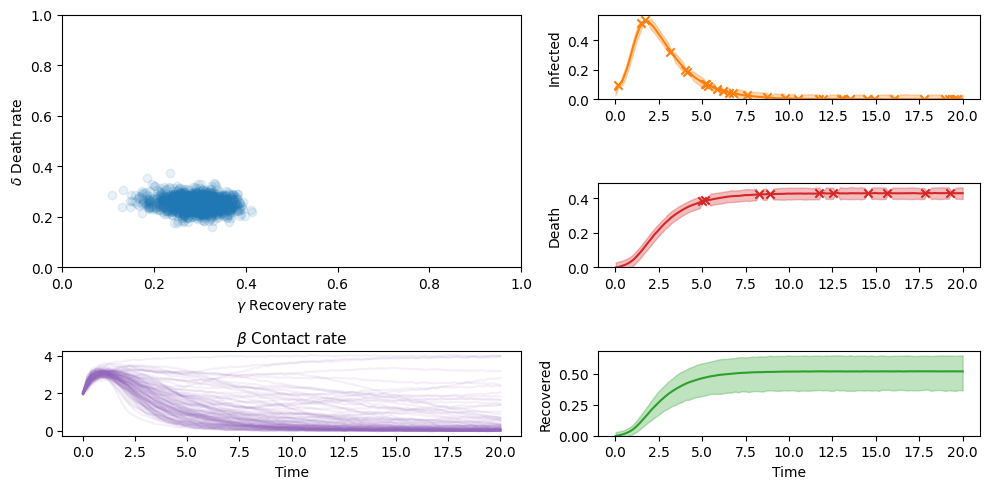

In [128]:
gamma = samples[:, 0:1]
delta = samples[:, 1:2]
betas = samples[:, 2:2+eval_time_points]
I = samples[:, 2+eval_time_points:2 + eval_time_points*2]
D = samples[:, 2+eval_time_points*2:2 + eval_time_points*3]
R = samples[:, 2+eval_time_points*3:2 + eval_time_points*4]

I_m = I.mean(axis=0)
I_min = jnp.quantile(I, 0.05, axis=0)
I_max = jnp.quantile(I, 0.95, axis=0)

D_m = D.mean(axis=0)
D_min = jnp.quantile(D, 0.05, axis=0)
D_max = jnp.quantile(D, 0.95, axis=0)

R_m = R.mean(axis=0)
R_min = jnp.quantile(R, 0.05, axis=0)
R_max = jnp.quantile(R, 0.95, axis=0)

fig = plt.figure(figsize=(10, 5))
grid = plt.GridSpec(3, 3, width_ratios=[1,1,2], height_ratios=[1,1,1])


ax_global = fig.add_subplot(grid[:2, :2])
ax_beta = fig.add_subplot(grid[2, :2])
ax_I = fig.add_subplot(grid[0, 2])
ax_D = fig.add_subplot(grid[1, 2])
ax_R = fig.add_subplot(grid[2, 2])

eval_time = jnp.linspace(time_start + 0.01, time_end , eval_time_points)

ax_global.scatter(gamma, delta, c='C0', alpha=0.1)
ax_global.set_xlim(0, 1)
ax_global.set_ylim(0, 1)
ax_global.set_xlabel(r"$\gamma$ Recovery rate")
ax_global.set_ylabel(r"$\delta$ Death rate")

ax_beta.plot(eval_time, betas[:100].T, c='C4', alpha=0.1)
ax_beta.set_title(r"$\beta$ Contact rate", fontsize=11)
ax_beta.set_xlabel("Time")

ax_I.plot(eval_time, I_m, c='C1')
ax_I.fill_between(eval_time, I_min, I_max, alpha=0.3, color='C1')
ax_I.set_ylabel("Infected")
ax_I.set_ylim(0)
ax_I.scatter(true_time_evals1, true_I, c='C1', marker='x')


ax_D.plot(eval_time, D_m, c='C3')
ax_D.fill_between(eval_time, D_min, D_max, alpha=0.3, color='C3')
ax_D.set_ylabel("Death")
ax_D.set_ylim(0)
ax_D.scatter(true_time_evals2, true_D, c='C3', marker='x')

ax_R.plot(eval_time, R_m, c='C2')
ax_R.fill_between(eval_time, R_min, R_max, alpha=0.3, color='C2')
ax_R.set_ylabel("Recovered")
ax_R.set_xlabel("Time")
ax_R.set_ylim(0)

plt.tight_layout()
plt.savefig("transformer_based_inference_diffusion_sir4.pdf", dpi=300)
plt.savefig("transformer_based_inference_diffusion_sir4.png", dpi=300)